##### Build model which will predict the profit that a startp company can have when R & D spend,Administration amount,marketing spend,state the organiztion is provided

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df.shape

(50, 5)

In [4]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


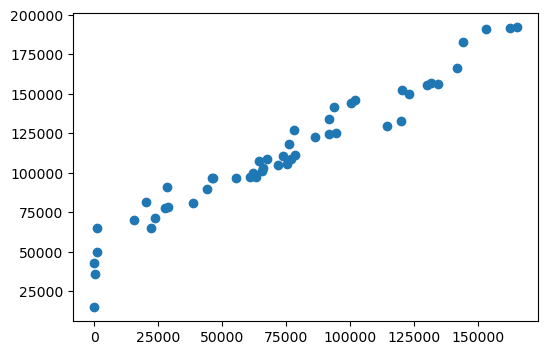

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["R&D Spend"], df["Profit"])
plt.show()

In [10]:
df.corr(numeric_only=True)

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

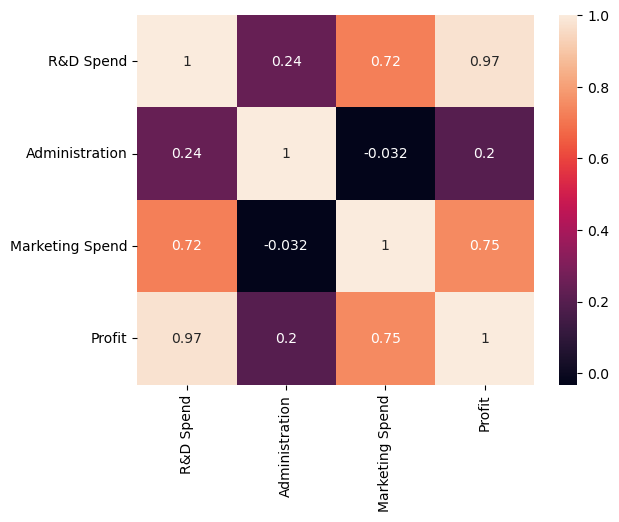

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot = True)

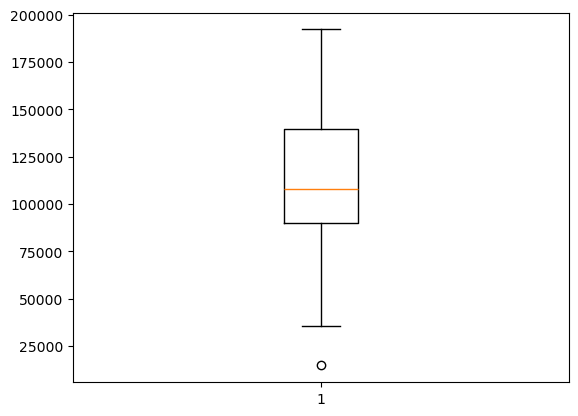

In [12]:
plt.boxplot(df["Profit"])
plt.show()

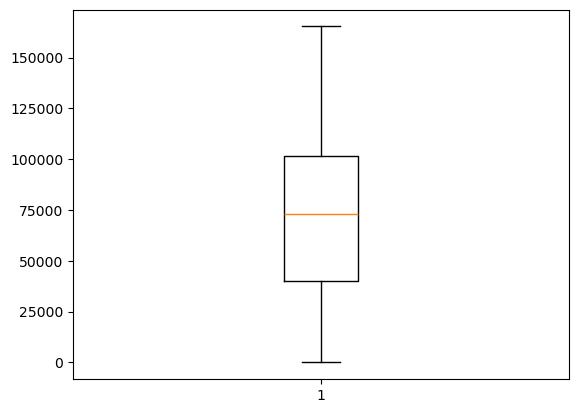

In [13]:
plt.boxplot(df["R&D Spend"])
plt.show()

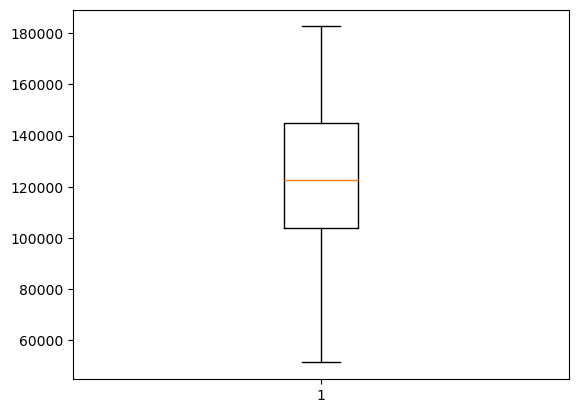

In [14]:
plt.boxplot(df["Administration"])
plt.show()

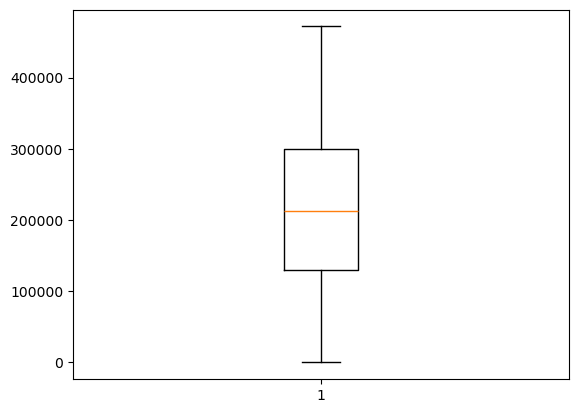

In [15]:
plt.boxplot(df["Marketing Spend"])
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])

In [17]:
X = df.iloc[:,:-1]

In [18]:
X

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,2
1,162597.70,151377.59,443898.53,0
2,153441.51,101145.55,407934.54,1
3,144372.41,118671.85,383199.62,2
4,142107.34,91391.77,366168.42,1
5,131876.90,99814.71,362861.36,2
6,134615.46,147198.87,127716.82,0
7,130298.13,145530.06,323876.68,1
8,120542.52,148718.95,311613.29,2
9,123334.88,108679.17,304981.62,0


In [19]:
y = df.iloc[:,-1]

In [20]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 ,random_state = 10)

In [22]:
X_train.shape

(40, 4)

In [23]:
X_test.shape

(10, 4)

In [24]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [25]:
lr

LinearRegression()

In [26]:
lr.fit(X_train,y_train)

LinearRegression()

In [29]:
y_test_predict = lr.predict(X_test)

In [30]:
from sklearn.metrics import r2_score,root_mean_squared_error

In [31]:
r2_score(y_test,y_test_predict)

0.9908827024290412

In [33]:
root_mean_squared_error(y_test,y_test_predict)

4066.9787469951884

In [27]:
lr.coef_ 

array([ 8.04328864e-01, -1.76830665e-02,  2.39891745e-02, -4.84762306e+02])

In [34]:
lr.intercept_

np.float64(50309.59099112514)

In [35]:
rnd = 100000
adm = 6700
mark = 450000
cl,ny,fl = 0,0,0

In [36]:
state = input('Enter State:')
if(state == 'California'):
    cl = 1
elif(state == 'New york'):
    ny = 1
else:
    fl = 1

Enter State: florida


In [37]:
cl,ny,fl

(0, 0, 1)

In [39]:
lr.predict([[rnd,adm,mark,state]])

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: dtype='numeric' is not compatible with arrays of bytes/strings.Convert your data to numeric values explicitly instead.